# Training Loop and Loss Construction: Token-Level or Sentence-Level?

> **Previous recap**: We already have a MiniGPT model. It takes token IDs and outputs logits. The parameters are still random, so now we need to train.
>
> **Core questions**:
> 1. How do we organize training data?
> 2. What is the loss actually computing?
> 3. Is training token-level, or sentence-level?
>
> In this part we use a tiny example and show how every number is computed.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)

### 1. Start from a super simple example

Assume we have a tiny model: vocab size 5, and we want to train it to predict the next token.

```
Vocab: [BOS=0, I=1, love=2, you=3, EOS=4]

Only one training sentence: "I love you"
Token IDs: [BOS, I, love, you, EOS]
         = [0,   1, 2,    3,   4]
```

**Training objective**: given the previous tokens, predict the next one.

```
given [BOS]                  -> predict I
given [BOS, I]               -> predict love
given [BOS, I, love]         -> predict you
given [BOS, I, love, you]    -> predict EOS
```

This looks like 4 independent prediction tasks, but Transformers have a trick: **they can predict all positions in parallel.**


### 2. Inputs and labels: one forward pass gives loss for all positions

This is the most important mental model. Look at this picture:

```
Training sentence: [BOS, I, love, you, EOS]
                  [0,   1, 2,    3,   4]

          +---------------------------------+
Input:     |  BOS  |   I   | love  |  you   |
          |  [0]  |  [1]  | [2]   | [3]    |
          +---------------------------------+
                    | model forward
          +---------------------------------+
Model out: | logits | logits| logits| logits|
          |  [0]   |  [1]  |  [2]  |  [3]  |
          +---------------------------------+
                    | each position predicts the next token
          +---------------------------------+
Targets:   |   I   | love  |  you  |  EOS  |
          |  [1]  | [2]   | [3]   | [4]   |
          +---------------------------------+

input  = drop the last token
labels = drop the first token (shift by 1)
```

This is called **teacher forcing**: we do not continue with the model's own predictions, we continue with the correct answers.

Why? Because then all positions can be trained **in parallel**, without waiting for earlier positions.


In [2]:
# A tiny hand-calculation demo of next-token prediction
sentence = torch.tensor([0, 1, 2, 3, 4])  # [BOS, I, love, you, EOS]

print("Full sentence:", sentence.tolist())
print()

# Input: drop the last token
input_ids = sentence[:-1]  # [0, 1, 2, 3]
print("Input (drop last token):", input_ids.tolist())
print("Meaning:                 [BOS,  I,   love,   you ]")
print()

# Labels: drop the first token (shift right by one)
target_ids = sentence[1:]  # [1, 2, 3, 4]
print("Labels (drop first token):", target_ids.tolist())
print("Meaning:                   [I,   love,   you,   EOS]")
print()

print("One-to-one mapping:")
for i in range(len(input_ids)):
    seen = ', '.join(str(x) for x in input_ids[: i + 1].tolist())
    print(f"  pos {i}: sees [{seen}] -> predict {target_ids[i].item()}")


Full sentence: [0, 1, 2, 3, 4]

Input (drop last token): [0, 1, 2, 3]
Meaning:                 [BOS,  I,   love,   you ]

Labels (drop first token): [1, 2, 3, 4]
Meaning:                   [I,   love,   you,   EOS]

One-to-one mapping:
  pos 0: sees [0] -> predict 1
  pos 1: sees [0, 1] -> predict 2
  pos 2: sees [0, 1, 2] -> predict 3
  pos 3: sees [0, 1, 2, 3] -> predict 4


### 3. How is loss computed? Cross-Entropy Loss

At each position the model outputs logits (one score per vocab item). We compare them against the labels.

We use **cross-entropy loss**:

```
For each position:
1. Convert logits to probabilities: softmax(logits)
2. Take the probability of the correct label
3. loss = -log(prob_correct)
4. Average over positions
```

**Intuition**:
- prob_correct = 1.0 -> loss = 0 (perfect)
- prob_correct = 0.01 -> loss = 4.6 (terrible)

Next we compute it step by step in code.


In [3]:
# Simulate model outputs (logits)
vocab_size = 5
seq_len = 4  # input length

# Pretend these logits came from the model. Here we generate them by hand for inspection.
torch.manual_seed(123)
logits = torch.randn(1, seq_len, vocab_size)   # [batch=1, seq_len=4, vocab=5]
targets = torch.tensor([[1, 2, 3, 4]])         # [batch=1, seq_len=4]

print(f"logits shape:  {logits.shape}")
print(f"labels shape:  {targets.shape}")
print()

print(f"pos 0 logits:  {logits[0, 0].tolist()}")
print(f"pos 0 label:   {targets[0, 0].item()}")
print(f"-> The model must pick the correct token id {targets[0, 0].item()} out of {vocab_size} options")


logits shape:  torch.Size([1, 4, 5])
labels shape:  torch.Size([1, 4])

pos 0 logits:  [0.3373701572418213, -0.1777772158384323, -0.3035275340080261, -0.5880124568939209, 1.5809690952301025]
pos 0 label:   1
-> The model must pick the correct token id 1 out of 5 options


In [4]:
# Compute cross-entropy loss by hand (so every number makes sense)
print("=== Cross-Entropy Loss computed by hand ===")
print()

total_loss = 0.0
for pos in range(seq_len):
    pos_logits = logits[0, pos]            # [vocab_size]
    correct_id = targets[0, pos].item()    # int

    # Step 1: softmax -> probabilities
    probs = F.softmax(pos_logits, dim=-1)

    # Step 2: probability of the correct class
    correct_prob = probs[correct_id].item()

    # Step 3: loss = -log(p(correct))
    pos_loss = -math.log(correct_prob)
    total_loss += pos_loss

    print(f"pos {pos}: correct={correct_id}, p={correct_prob:.4f}, loss={pos_loss:.4f}")

manual_loss = total_loss / seq_len
print()
print(f"mean loss over positions: {manual_loss:.4f}")

# Compare to PyTorch
pt_loss = F.cross_entropy(
    logits.reshape(-1, vocab_size),
    targets.reshape(-1),
).item()
print(f"PyTorch cross_entropy:     {pt_loss:.4f}")
print(f"Match? {'[ok]' if abs(manual_loss - pt_loss) < 1e-4 else '[x]'}")


=== Cross-Entropy Loss computed by hand ===

pos 0: correct=1, p=0.0998, loss=2.3050
pos 1: correct=2, p=0.0853, loss=2.4619
pos 2: correct=3, p=0.3147, loss=1.1561
pos 3: correct=4, p=0.6087, loss=0.4965

mean loss over positions: 1.6049
PyTorch cross_entropy:     1.6049
Match? [ok]


### 4. Token-level training or sentence-level training?

**Answer: token-level training.**

But note: it's token-level **and parallel**, not token-by-token serial training.

```
+----------------------------------------------+
|              one forward + backward           |
|                                              |
|  Loss = loss(pos0) + loss(pos1) + ...         |
|                                              |
|  pos 0 predicts token 1                       |
|  pos 1 predicts token 2    } all computed     |
|  pos 2 predicts token 3    } in parallel      |
|  pos 3 predicts token 4                       |
|                                              |
|  gradients sum over all positions             |
|  update parameters <- learning signals from   |
|                      all positions            |
+----------------------------------------------+
```

**Why not sentence-level?**
- Sentence-level means supervising only one position (e.g. at the end) -> signal is too sparse.
- For a 100-token sentence, you'd get only one supervision signal.
- Token-level gives ~100 supervision signals.

**But it is also NOT serial token training.** It is parallel: one forward pass produces all losses.
That is one reason Transformers train much faster than RNNs.


### 5. Training multiple sentences in a batch

Real training does not train on only one sentence. We train batches (e.g. 32 sequences) as a matrix.

```
Batch input:
[[BOS,  I,    love, you,  EOS,  PAD,  PAD],   <- sentence 1 (5 valid tokens)
 [BOS,  hello,world,EOS,  PAD,  PAD,  PAD]]   <- sentence 2 (4 valid tokens)

Shape: [batch_size=2, seq_len=7]
```

Loss: average over all positions across all sentences (excluding PAD positions).

```python
loss = cross_entropy(logits.reshape(-1, vocab), targets.reshape(-1), ignore_index=PAD_ID)
#                                                         ^ ignore padding
```


In [5]:
# Demo: loss on a padded batch
PAD_ID = 0  # assume token id 0 is PAD

batch_input = torch.tensor([
    [0, 1, 2, 3, 4, 0, 0],  # [BOS, I, love, you, EOS, PAD, PAD]
    [0, 2, 4, 0, 0, 0, 0],  # [BOS, love, EOS, PAD, PAD, PAD, PAD]
])

# Labels = input shifted by one
batch_target = torch.tensor([
    [1, 2, 3, 4, 0, 0, 0],
    [2, 4, 0, 0, 0, 0, 0],
])

print("Batch input:")
print(batch_input)
print()
print("Batch labels:")
print(batch_target)
print()

# Simulate logits
batch_logits = torch.randn(2, 7, 5)  # [batch=2, seq=7, vocab=5]

# Key: ignore_index=PAD_ID, so PAD positions do not contribute to loss
loss_with_ignore = F.cross_entropy(
    batch_logits.reshape(-1, 5),
    batch_target.reshape(-1),
    ignore_index=PAD_ID,
)

loss_without_ignore = F.cross_entropy(
    batch_logits.reshape(-1, 5),
    batch_target.reshape(-1),
)

print(f"loss (ignore PAD):     {loss_with_ignore.item():.4f}")
print(f"loss (do not ignore):  {loss_without_ignore.item():.4f}")
print()
print("Big difference: PAD positions are meaningless and should not affect training.")


Batch input:
tensor([[0, 1, 2, 3, 4, 0, 0],
        [0, 2, 4, 0, 0, 0, 0]])

Batch labels:
tensor([[1, 2, 3, 4, 0, 0, 0],
        [2, 4, 0, 0, 0, 0, 0]])

loss (ignore PAD):     2.3260
loss (do not ignore):  2.3044

Big difference: PAD positions are meaningless and should not affect training.


### 6. The complete training loop

Now we combine everything.
Because we have not trained a real tokenizer yet, we use a **toy setting** to demonstrate the full training loop.


In [6]:
# Reuse a simplified MiniGPT (from Part 4)
def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=4, max_seq_len=128):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
        
        self.token_emb = nn.Embedding(vocab_size, d_model)
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)
        
        # Simplification: no ModuleList, just write a couple of blocks
        self.attn1 = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.ffn1 = nn.Sequential(
            nn.Linear(d_model, 4*d_model), nn.ReLU(), nn.Linear(4*d_model, d_model)
        )
        self.norm1a = nn.LayerNorm(d_model)
        self.norm1f = nn.LayerNorm(d_model)
        
        self.attn2 = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.ffn2 = nn.Sequential(
            nn.Linear(d_model, 4*d_model), nn.ReLU(), nn.Linear(4*d_model, d_model)
        )
        self.norm2a = nn.LayerNorm(d_model)
        self.norm2f = nn.LayerNorm(d_model)
        
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
    
    def forward(self, x):
        batch_size, seq_len = x.shape
        x = self.token_emb(x) + self.pe[:seq_len, :]
        
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        
        # Block 1
        attn_out, _ = self.attn1(x, x, x, attn_mask=mask)
        x = self.norm1a(x + attn_out)
        x = self.norm1f(x + self.ffn1(x))
        
        # Block 2
        attn_out, _ = self.attn2(x, x, x, attn_mask=mask)
        x = self.norm2a(x + attn_out)
        x = self.norm2f(x + self.ffn2(x))
        
        x = self.ln_final(x)
        return self.lm_head(x)

print("MiniGPT model defined. [ok]")


MiniGPT model defined. [ok]


In [7]:
# === A complete training loop demo ===

# 1) Prepare fake data (already tokenized)
VOCAB_SIZE = 20
PAD_ID = 0
SEQ_LEN = 16
BATCH_SIZE = 8

# Fake data: random token sequences
train_data = torch.randint(1, VOCAB_SIZE, (100, SEQ_LEN))  # 100 sequences
print(f"train data: {train_data.shape} (100 sequences, each {SEQ_LEN} tokens)")

# 2) Create a model
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(f"model parameters: {sum(p.numel() for p in model.parameters()):,}")


train data: torch.Size([100, 16]) (100 sequences, each 16 tokens)
model parameters: 102,676


In [8]:
# 3) Training loop
NUM_EPOCHS = 5
losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    num_batches = 0
    
    for i in range(0, len(train_data), BATCH_SIZE):
        batch = train_data[i:i+BATCH_SIZE]  # [batch_size, seq_len]
        
        # Prepare inputs and labels
        input_ids = batch[:, :-1]      # drop last token
        target_ids = batch[:, 1:]       # drop first token
        
        # Forward
        logits = model(input_ids)  # [batch, seq_len-1, vocab_size]
        
        # Loss: flatten batch and positions
        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),  # [batch*(seq_len-1), vocab_size]
            target_ids.reshape(-1)            # [batch*(seq_len-1)]
        )
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}")

print(f"\nLoss from {losses[0]:.4f} down to {losses[-1]:.4f} -> the model is learning!")


Epoch 1/5 | Loss: 3.0834
Epoch 2/5 | Loss: 2.9192
Epoch 3/5 | Loss: 2.8793
Epoch 4/5 | Loss: 2.8393
Epoch 5/5 | Loss: 2.7892

Loss from 3.0834 down to 2.7892 -> the model is learning!


Falling loss = the model is learning to predict the next token


<cell>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


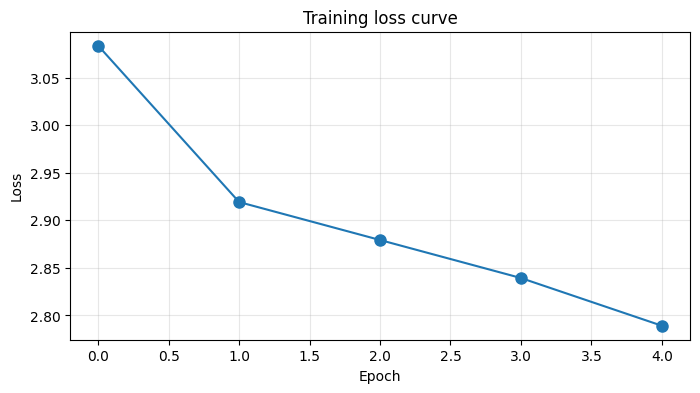

In [9]:
# Visualize the loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses, 'o-', markersize=8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss curve')
plt.grid(True, alpha=0.3)
plt.show()

print("Falling loss = the model is learning to predict the next token")


### 7. Core recap: one diagram to settle it

```
+--------------------------------------------------------+
|     What does token-level training really mean?         |
+--------------------------------------------------------+
|                                                        |
|  full seq:   [BOS, I, love, you, C, h, EOS]             |
|              | drop the last token                      |
|  model in:   [BOS, I, love, you, C, h]                  |
|              | forward                                  |
|  model out:  [logits_0, logits_1, ..., logits_5]        |
|              | compare with labels                      |
|  labels:     [I, love, you, C, h, EOS]                  |
|                                                        |
|  Loss = mean(loss_0, loss_1, ..., loss_5)               |
|              | backward                                 |
|  gradients from all positions -> update parameters      |
|                                                        |
|  [ok] token-level: each position contributes loss       |
|  [ok] parallel: one forward predicts all positions      |
|  [x] not sentence-level: not only the last position     |
|  [x] not serial tokens: no waiting token by token       |
|                                                        |
+--------------------------------------------------------+
```


### 8. A common confusion: training vs inference

| | training | inference / generation |
|:---|:---|:---|
| Input | full sentence (drop last token) | only a prompt |
| Computation | parallel over positions | token-by-token serial |
| Labels | ground truth (teacher forcing) | previous token generated by the model |
| Mask | hide the future | hide the future |
| Loss | computed | not computed |

**Key difference**:
- training uses teacher forcing -> parallel -> fast
- inference has no answers -> must generate serially -> slow

-> Next part: autoregressive generation.


### 9. Gradient view: what happens after computing loss?

Loss is just one number.
What actually drives learning is the **gradient**.

```
loss (one number)
    | backward
grads (one number per parameter)
    | optimizer.step
params update (model becomes slightly better)
```

This section focuses on gradients, the step people often skip.


#### 9.1 Backpropagation: how gradients flow from loss back to parameters

**Intuition**: loss is the result of all parameters together.
Backprop asks:

> If I increase a parameter by a tiny amount, how much does loss change?

That rate of change is the gradient.

A simplest example (one neuron):

```
input x -> [weight w] -> y = w * x
                     |
                  loss = (y - target)^2
```

**Chain rule**:

```
\partial loss / \partial w = (\partial loss / \partial y) * (\partial y / \partial w)
                           = 2 (y - target) * x
```

In LLMs the chain passes through many Transformer blocks, but the principle is identical.


In [10]:
# A tiny backprop demo on a 1D linear model
print("=== Backpropagation by hand (tiny demo) ===")
print()

w = torch.tensor([0.5], requires_grad=True)
b = torch.tensor([0.1], requires_grad=True)

x = torch.tensor([2.0])
target = torch.tensor([3.0])

print(f"params: w={w.item():.2f}, b={b.item():.2f}")
print(f"input x={x.item():.2f}, target={target.item():.2f}")
print()

# Forward
y = w * x + b
loss = (y - target) ** 2

print(f"Forward: y = w*x + b = {w.item()}*{x.item()} + {b.item()} = {y.item():.2f}")
print(f"Loss = (y - target)^2 = ({y.item():.2f} - {target.item():.2f})^2 = {loss.item():.2f}")
print()

# Backward
loss.backward()

print(f"dloss/dw = {w.grad.item():.4f}  (meaning: if w increases by 1, loss changes by {w.grad.item():.4f})")
print(f"dloss/db = {b.grad.item():.4f}  (meaning: if b increases by 1, loss changes by {b.grad.item():.4f})")
print()

# Chain rule check
print("=== Chain rule check ===")
dloss_dy = 2 * (y.item() - target.item())
print(f"dloss/dy = 2*(y - target) = 2*({y.item():.2f} - {target.item():.2f}) = {dloss_dy:.2f}")
print(f"dy/dw = x = {x.item():.2f}")
print("dy/db = 1")
print(f"dloss/dw = dloss/dy * dy/dw = {dloss_dy:.2f} * {x.item():.2f} = {dloss_dy*x.item():.2f}")
print(f"PyTorch dloss/dw = {w.grad.item():.4f}  [ok]")


=== Backpropagation by hand (tiny demo) ===

params: w=0.50, b=0.10
input x=2.00, target=3.00

Forward: y = w*x + b = 0.5*2.0 + 0.10000000149011612 = 1.10
Loss = (y - target)^2 = (1.10 - 3.00)^2 = 3.61

dloss/dw = -7.6000  (meaning: if w increases by 1, loss changes by -7.6000)
dloss/db = -3.8000  (meaning: if b increases by 1, loss changes by -3.8000)

=== Chain rule check ===
dloss/dy = 2*(y - target) = 2*(1.10 - 3.00) = -3.80
dy/dw = x = 2.00
dy/db = 1
dloss/dw = dloss/dy * dy/dw = -3.80 * 2.00 = -7.60
PyTorch dloss/dw = -7.6000  [ok]


In [11]:
# Inspect gradient flow in MiniGPT
VOCAB_SIZE = 20
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)

dummy_input = torch.randint(1, VOCAB_SIZE, (2, 16))   # [batch=2, seq=16]
dummy_target = torch.randint(1, VOCAB_SIZE, (2, 15))  # [batch=2, seq=15]

# Forward
logits = model(dummy_input[:, :-1])
loss = F.cross_entropy(
    logits.reshape(-1, VOCAB_SIZE),
    dummy_target.reshape(-1),
)

# Backward
model.zero_grad()
loss.backward()

print("=== MiniGPT per-parameter gradient norms ===")
print()
print(f"{'Parameter':<40s} {'grad_norm':>12s} {'shape':>18s}")
print("-" * 72)

total_grad_norm = 0.0
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        total_grad_norm += grad_norm ** 2
        param_shape = str(list(param.shape))
        print(f"{name:<40s} {grad_norm:>12.6f}  {param_shape:>18s}")

total_grad_norm = total_grad_norm ** 0.5
print("-" * 72)
print(f"{'total_grad_norm (L2)':<40s} {total_grad_norm:>12.6f}")
print()
print("Observations:")
print("  1) Every parameter has a gradient -> backprop reached all layers")
print("  2) lm_head often has larger gradients -> loss signal is strongest near the output")
print("  3) embeddings may have smaller gradients -> signal goes through many layers")
print("  4) residual connections help prevent vanishing gradients")


=== MiniGPT per-parameter gradient norms ===

Parameter                                   grad_norm              shape
------------------------------------------------------------------------
token_emb.weight                             0.101909            [20, 64]
attn1.in_proj_weight                         0.530080           [192, 64]
attn1.in_proj_bias                           0.073851               [192]
attn1.out_proj.weight                        0.558048            [64, 64]
attn1.out_proj.bias                          0.120992                [64]
ffn1.0.weight                                0.383593           [256, 64]
ffn1.0.bias                                  0.054850               [256]
ffn1.2.weight                                0.806044           [64, 256]
ffn1.2.bias                                  0.140561                [64]
norm1a.weight                                0.096144                [64]
norm1a.bias                                  0.141295               

#### 9.2 Token-level gradients: not all tokens are equally important

We said each token contributes to loss. But do they contribute equally?

No.

```
"The capital of France is Paris"
        easy            medium        key info
     (small loss)                  (large loss)
```

- High-frequency tokens like "is" become easy -> small loss -> small gradients
- Content tokens like "Paris" -> larger loss -> larger gradients

So training signal is mostly driven by the hard/content tokens.

This connects to a key RL training issue (e.g. Shuffle-R1): advantage collapsing.
If most rollouts have advantage close to 0, gradient signals become weak.


In [12]:
# Demo: token positions have different losses -> different gradient contributions
print("=== Token-level loss analysis ===")
print()

VOCAB_SIZE = 20
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)

# Build a sequence: first half is an easy repeating pattern, second half is random
# Easy pattern: [1,2,3,1,2,3,...]
easy_part = torch.tensor([1, 2, 3, 1, 2, 3, 1, 2, 3])
hard_part = torch.randint(10, VOCAB_SIZE, (7,))
sentence = torch.cat([easy_part, hard_part])  # seq_len=16
batch = sentence.unsqueeze(0)  # [1, 16]

input_ids = batch[:, :-1]   # [1, 15]
target_ids = batch[:, 1:]   # [1, 15]

print(f"easy half (pattern): {easy_part.tolist()}")
print(f"hard half (random):  {hard_part.tolist()}")
print()

logits = model(input_ids)  # [1, 15, vocab]

print("loss at each position:")
print(f"{'pos':>4s} {'token':>6s} {'loss':>10s} {'region':>10s}")
print("-" * 44)

for pos in range(15):
    pos_logits = logits[0, pos]
    pos_target = target_ids[0, pos]
    pos_loss = F.cross_entropy(pos_logits.unsqueeze(0), pos_target.unsqueeze(0)).item()
    region = "easy" if pos < 8 else "hard"
    print(f"{pos:>4d} {pos_target.item():>6d} {pos_loss:>10.4f}  {region:>10s}")

logits_flat = logits.reshape(-1, VOCAB_SIZE)
targets_flat = target_ids.reshape(-1)
all_losses = F.cross_entropy(logits_flat, targets_flat, reduction='none')

easy_avg = all_losses[:9].mean().item()
hard_avg = all_losses[9:].mean().item()

print()
print(f"avg loss (easy): {easy_avg:.4f}")
print(f"avg loss (hard): {hard_avg:.4f}")
print(f"hard/easy ratio: {hard_avg/easy_avg:.2f}x")
print()
print("-> Hard tokens produce larger gradients and drive more learning.")


=== Token-level loss analysis ===

easy half (pattern): [1, 2, 3, 1, 2, 3, 1, 2, 3]
hard half (random):  [16, 15, 19, 12, 10, 15, 11]

loss at each position:
 pos  token       loss     region
--------------------------------------------
   0      2     3.3892        easy
   1      3     3.0641        easy
   2      1     3.6150        easy
   3      2     3.2807        easy
   4      3     3.3134        easy
   5      1     3.7741        easy
   6      2     3.3445        easy
   7      3     3.6809        easy
   8     16     2.5280        hard
   9     15     3.1226        hard
  10     19     4.2208        hard
  11     12     2.0640        hard
  12     10     2.5653        hard
  13     15     3.6926        hard
  14     11     3.2925        hard

avg loss (easy): 3.3322
avg loss (hard): 3.1596
hard/easy ratio: 0.95x

-> Hard tokens produce larger gradients and drive more learning.


In [13]:
# Advanced: visualize token-level gradient contribution (toy simulation)
print("=== Token-level gradient contribution (toy) ===")
print()

torch.manual_seed(42)

# Simulated per-token loss (small at first, larger later)
token_losses = torch.tensor([
    0.1, 0.15, 0.2, 0.15, 0.1,
    0.3, 0.5, 0.8, 1.2, 1.5,
    2.0, 2.5, 2.8, 3.0, 3.2,
    3.5, 3.8, 4.0, 4.2, 4.5,
])

tokens = [
    "BOS", "I", "am", "an", "AI",
    "today", "the", "weather", "is", "nice",
    "quantum", "entanglement", "is", "a", "nonlocal",
    "physics", "phenomenon", "one", ",", "EOS",
]

# Simplification: gradient contribution ~ loss
grad_contrib = token_losses / token_losses.sum() * 100

print("Token-level gradient contribution:")
print(f"{'Token':<12s} {'Loss':>8s} {'grad_%':>8s} {'bar'}")
print("-" * 60)

threshold = 5.0
high_count = 0
for i in range(len(tokens)):
    bar_len = int(grad_contrib[i].item() * 2)
    bar = "#" * bar_len
    marker = " *" if grad_contrib[i] > threshold else ""
    if grad_contrib[i] > threshold:
        high_count += 1
    print(f"{tokens[i]:<12s} {token_losses[i].item():>8.2f} {grad_contrib[i].item():>7.1f}% {bar}{marker}")

print()
print(f"tokens with grad_% > {threshold}%: {high_count}/{len(tokens)}")
print()
print("Key insights:")
print("  1) Early, frequent tokens may contribute little gradient")
print("  2) Later, harder content tokens contribute most gradient")
print("  3) Training efficiency is often dominated by the hardest tokens")


=== Token-level gradient contribution (toy) ===

Token-level gradient contribution:
Token            Loss   grad_% bar
------------------------------------------------------------
BOS              0.10     0.3% 
I                0.15     0.4% 
am               0.20     0.5% #
an               0.15     0.4% 
AI               0.10     0.3% 
today            0.30     0.8% #
the              0.50     1.3% ##
weather          0.80     2.1% ####
is               1.20     3.1% ######
nice             1.50     3.9% #######
quantum          2.00     5.2% ########## *
entanglement     2.50     6.5% ############ *
is               2.80     7.3% ############## *
a                3.00     7.8% ############### *
nonlocal         3.20     8.3% ################ *
physics          3.50     9.1% ################## *
phenomenon       3.80     9.9% ################### *
one              4.00    10.4% #################### *
,                4.20    10.9% ##################### *
EOS              4.50    11.

#### 9.3 Gradient clipping: prevent gradient explosion

**Problem**: sometimes a batch produces very large gradients.
If the optimizer takes a huge step, loss can become NaN and training collapses.

**Solution**: gradient clipping.

```
if ||grad||_2 > max_norm:
    scale gradients down to make the norm = max_norm
else:
    keep unchanged
```

In LLM training clipping is very common, often `max_norm=1.0`.


In [14]:
# Gradient clipping demo
print("=== Gradient clipping demo ===")
print()

# Build a small network and intentionally create a large gradient
linear = nn.Linear(10, 1)

x = torch.randn(5, 10)
target = torch.randn(5, 1) * 100  # scale up target to blow up gradients

# Without clipping
loss = F.mse_loss(linear(x), target)
loss.backward()
raw_grad_norm = sum(p.grad.norm().item() ** 2 for p in linear.parameters()) ** 0.5
print(f"grad_norm without clipping: {raw_grad_norm:.4f}")

# Reset
torch.nn.utils.clip_grad_norm_(linear.parameters(), 0.0)
linear.zero_grad()

# With clipping
loss = F.mse_loss(linear(x), target)
loss.backward()
max_norm = 1.0
nn.utils.clip_grad_norm_(linear.parameters(), max_norm)
clipped_grad_norm = sum(p.grad.norm().item() ** 2 for p in linear.parameters()) ** 0.5

print(f"grad_norm with clipping:    {clipped_grad_norm:.4f} (cap={max_norm})")
print()
print("If gradients explode, clipping can keep training stable.")
print()
print("Practical snippet:")
print("```python")
print("loss.backward()")
print("torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)")
print("optimizer.step()")
print("```")


=== Gradient clipping demo ===

grad_norm without clipping: 263.0871
grad_norm with clipping:    1.0000 (cap=1.0)

If gradients explode, clipping can keep training stable.

Practical snippet:
```python
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```


#### 9.4 Gradient accumulation: simulate a large batch on a small GPU

**Problem**: training wants big batch (e.g. 512), but your GPU fits batch=4.

Key observation:

```
Grad(batch=8) = Grad(batch=4) + Grad(batch=4)
```

So you can run many micro-batches, accumulate gradients, and call `optimizer.step()` once.


In [15]:
# Gradient accumulation demo
print("=== Gradient accumulation demo ===")
print()

VOCAB_SIZE = 20
model_small = MiniGPT(VOCAB_SIZE, d_model=32, num_heads=2, num_layers=1)
model_large = MiniGPT(VOCAB_SIZE, d_model=32, num_heads=2, num_layers=1)

# Copy the same parameters
model_large.load_state_dict(model_small.state_dict())

# Fake data: 16 sequences total
all_data = torch.randint(1, VOCAB_SIZE, (16, 16))

# A) Large batch (batch=16)
opt_large = torch.optim.SGD(model_large.parameters(), lr=0.01)

input_large = all_data[:, :-1]
target_large = all_data[:, 1:]
logits_large = model_large(input_large)
loss_large = F.cross_entropy(logits_large.reshape(-1, VOCAB_SIZE), target_large.reshape(-1))
opt_large.zero_grad()
loss_large.backward()

grads_large = {name: p.grad.clone() for name, p in model_large.named_parameters() if p.grad is not None}
opt_large.step()

# B) Small batch (batch=4) + accumulate 4 steps
opt_small = torch.optim.SGD(model_small.parameters(), lr=0.01)
opt_small.zero_grad()

ACCUM_STEPS = 4
small_batch_size = 4
for step in range(ACCUM_STEPS):
    start = step * small_batch_size
    end = start + small_batch_size
    mini_batch = all_data[start:end]

    input_small = mini_batch[:, :-1]
    target_small = mini_batch[:, 1:]
    logits_small = model_small(input_small)
    loss_small = F.cross_entropy(logits_small.reshape(-1, VOCAB_SIZE), target_small.reshape(-1))

    # Key: divide loss by ACCUM_STEPS to match the gradient scale
    (loss_small / ACCUM_STEPS).backward()
    print(f"  accum step {step+1}/{ACCUM_STEPS}: loss={loss_small.item():.4f} (grads accumulated)")

print()

grads_small = {name: p.grad.clone() for name, p in model_small.named_parameters() if p.grad is not None}
opt_small.step()

print("=== Gradient comparison ===")
all_close = True
for name in grads_large:
    diff = (grads_large[name] - grads_small[name]).norm().item()
    status = "[ok]" if diff < 1e-4 else "[x]"
    if diff >= 1e-4:
        all_close = False
    print(f"  {name:<30s} diff={diff:.8f} {status}")

print()
if all_close:
    print("Conclusion: accumulated gradients == large-batch gradients [ok]")
    print("-> 4 steps of batch=4 behaves like 1 step of batch=16")
else:
    print("Note: with BatchNorm you can see differences due to running stats")
    print("But for LLMs (LayerNorm), this is effectively equivalent")


=== Gradient accumulation demo ===

  accum step 1/4: loss=3.2385 (grads accumulated)
  accum step 2/4: loss=3.1230 (grads accumulated)
  accum step 3/4: loss=3.3044 (grads accumulated)
  accum step 4/4: loss=3.2764 (grads accumulated)

=== Gradient comparison ===
  token_emb.weight               diff=0.00000000 [ok]
  attn1.in_proj_weight           diff=0.00000006 [ok]
  attn1.in_proj_bias             diff=0.00000000 [ok]
  attn1.out_proj.weight          diff=0.00000006 [ok]
  attn1.out_proj.bias            diff=0.00000001 [ok]
  ffn1.0.weight                  diff=0.00000002 [ok]
  ffn1.0.bias                    diff=0.00000000 [ok]
  ffn1.2.weight                  diff=0.00000005 [ok]
  ffn1.2.bias                    diff=0.00000000 [ok]
  norm1a.weight                  diff=0.00000001 [ok]
  norm1a.bias                    diff=0.00000001 [ok]
  norm1f.weight                  diff=0.00000001 [ok]
  norm1f.bias                    diff=0.00000001 [ok]
  attn2.in_proj_weight           

#### 9.5 Gradient flow panorama (LLM)

Let us connect everything we have learned so far and look at the full "life of a gradient" in LLM training:

```text
┌─────────────────────────────────────────────────────────────────┐
│                   Gradient Flow Panorama (LLM)                  │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  [Data]                                                         │
│    ↓                                                            │
│  [Forward: input -> Embedding -> Transformer blocks -> LM head] │
│    ↓                                                            │
│  [Loss: Cross-Entropy, one loss per token]                      │
│    │                                                            │
│    │  <- Key observation 1: token-level gradients               │
│    │     easy tokens ("the", "is") -> small loss -> small grad    │
│    │     hard tokens ("Paris")     -> big loss   -> big grad      │
│    │     training is driven mostly by the hard tokens           │
│    ↓                                                            │
│  [Backward: gradients flow back from LM head]                   │
│    │                                                            │
│    ├── LayerNorm: normalizes, helps stability                   │
│    ├── FFN: two Linear layers, gradients can be large           │
│    ├── Attention: Q/K/V projections + output projection         │
│    │     │                                                      │
│    │     └── <- Key observation 2: head-wise gradient mismatch  │
│    │           some heads are active (large grads),             │
│    │           some heads are redundant (small grads)           │
│    ├── Residual connections -> gradients take a shortcut <- key │
│    │                                                            │
│    ↓ back to the Embedding layer (often smaller grads)          │
│                                                                 │
│  [Gradient handling]                                            │
│    ├── Gradient clipping: prevent explosion, max_norm ~ 1.0     │
│    ├── Gradient accumulation: small GPU simulates large batch   │
│    └── (RL-specific) rollout filtering: keep high-signal data   │
│                                                                 │
│  [Parameter update: optimizer.step()]                           │
│    ↓                                                            │
│  [Next batch, repeat]                                           │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

**The three most important takeaways**:

1. **Residual connections are gradient highways**.
   Without them, deep Transformers can suffer vanishing gradients (similar to deep RNNs).
   Residual paths let gradients skip FFN and attention and flow backward more directly.

2. **Token-level gradients are highly uneven**.
   Easy/common tokens contribute little; hard/informative tokens dominate training.
   This helps explain why "knowledge-heavy" improvements can be slow: the knowledge tokens are rare.

3. **RL-style training makes gradient sparsity worse**.
   In SFT, every token has a target label.
   In RL, many rollouts have near-zero advantage, so the gradient signal can be much sparser.


In [16]:
# Visual intuition: residual connections protect gradient flow
print("=== Residual connections and gradient flow ===")
print()

print("Without residuals (traditional deep net):")
print("  Input -> Layer1 -> Layer2 -> ... -> Layer32 -> Output")
print("  gradient: Output -> Layer32 -> ... -> Layer1 -> Input")
print("  Problem: multiplying many Jacobians can shrink gradients to ~0 (vanishing)")
print()

print("With residuals (Transformer style):")
print("  Input -> [Layer1 + Input] -> [Layer2 + prev] -> ... -> Output")
print("  gradient has two paths:")
print("    main path: Output -> Layer32 -> ... -> Layer1 -> Input  (may shrink)")
print("    skip path: Output -> Input  (bypasses all layers)")
print()
print("Because the skip path exists, some gradient can reach early layers more directly.")
print()

# Simple decay simulation
depths = [1, 4, 8, 16, 32, 64]
print("Simulation: start grad=1.0, decay per layer")
print(f"{'depth':>6s}  {'no_residual':>12s}  {'with_residual':>14s}")
print("-" * 38)

decay_per_layer = 0.95
skip_ratio = 0.3

for d in depths:
    no_skip = decay_per_layer ** d
    with_skip = no_skip * (1 - skip_ratio) + skip_ratio
    print(f"{d:>6d}  {no_skip:>12.6f}  {with_skip:>14.6f}")

print()
print("Conclusion: residuals matter more as depth increases.")


=== Residual connections and gradient flow ===

Without residuals (traditional deep net):
  Input -> Layer1 -> Layer2 -> ... -> Layer32 -> Output
  gradient: Output -> Layer32 -> ... -> Layer1 -> Input
  Problem: multiplying many Jacobians can shrink gradients to ~0 (vanishing)

With residuals (Transformer style):
  Input -> [Layer1 + Input] -> [Layer2 + prev] -> ... -> Output
  gradient has two paths:
    main path: Output -> Layer32 -> ... -> Layer1 -> Input  (may shrink)
    skip path: Output -> Input  (bypasses all layers)

Because the skip path exists, some gradient can reach early layers more directly.

Simulation: start grad=1.0, decay per layer
 depth   no_residual   with_residual
--------------------------------------
     1      0.950000        0.965000
     4      0.814506        0.870154
     8      0.663420        0.764394
    16      0.440127        0.608089
    32      0.193711        0.435598
    64      0.037524        0.326267

Conclusion: residuals matter more as dep

#### 9.6 Gradient summary

| Concept | One line | Why it matters |
|:---|:---|:---|
| Backprop | loss -> chain rule -> gradients | foundation of learning |
| Token-level grads | hard tokens dominate | explains training efficiency |
| Clipping | cap gradient norm | prevents blow-ups |
| Accumulation | sum micro-batch grads | small GPU trick |
| Residual | grads can skip layers | enables deep Transformers |
| RL sparsity | fewer effective grads | RL stabilization motivation |

Gradients translate "what went wrong" into "how each parameter should change".


---

## Part Summary

1. [ok] input = full sentence without last token; labels = full sentence without first token
2. [ok] all positions predict in parallel; cross-entropy loss per position
3. [ok] total loss = mean over valid positions
4. [ok] token-level but parallel (not sentence-level, not serial tokens)
5. [ok] training uses teacher forcing; inference must generate serially
6. [ok] PAD positions are excluded via `ignore_index`

These ideas apply to all autoregressive LMs.

-> Next: generation.


### 10. From dialogue to tokens: what does JSONL actually feed the model?

A chat template formats messages into one continuous token sequence.

#### 10.1 Real training data (JSONL)

```jsonl
{"messages": [{"role": "system", "content": "You are a math assistant"}, {"role": "user", "content": "1+1=?"}, {"role": "assistant", "content": "1+1=2"}]}
{"messages": [{"role": "user", "content": "Hello"}, {"role": "assistant", "content": "Hi! How can I help?"}]}
{"messages": [{"role": "system", "content": "You are a translator"}, {"role": "user", "content": "Hello"}, {"role": "assistant", "content": "Hi"}]}
```

Core questions:
1. How messages are concatenated into one sequence
2. Which tokens are context vs targets
3. How special tokens are handled in loss


In [17]:
# ============================================================
# Inspect what a chat template does (Hugging Face)
# ============================================================
print("=== Real tokenizer demo: how chat templates turn messages into tokens ===")
print()

from transformers import AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = None
try:
    print(f"Loading tokenizer: {MODEL_NAME}")
    print("(On first run this may download a small tokenizer file.)")
    print()

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

    print("=== Special tokens ===")
    print(f"  bos_token: {repr(tokenizer.bos_token)} -> id={tokenizer.bos_token_id}")
    print(f"  eos_token: {repr(tokenizer.eos_token)} -> id={tokenizer.eos_token_id}")
    print(f"  pad_token: {repr(tokenizer.pad_token)} -> id={tokenizer.pad_token_id}")
    print(f"  vocab size: {len(tokenizer)} tokens")
    print()

    print("=== Chat template (Jinja2) ===")
    ct = tokenizer.chat_template
    if ct:
        print(ct[:500])
        print("...")
    print()

    messages = [
        {"role": "system", "content": "You are a helpful math assistant."},
        {"role": "user", "content": "What is 1+1?"},
        {"role": "assistant", "content": "1+1=2."},
    ]

    print("=== Input: messages ===")
    import json as _json
    print(_json.dumps(messages, ensure_ascii=False, indent=2))
    print()

    print("=== Step 1: apply_chat_template(tokenize=False) -> rendered text ===")
    rendered_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    print("Rendered text repr:")
    print(repr(rendered_text))
    print()
    print("Rendered text (human-readable):")
    print(rendered_text)
    print()

    print("=== Step 2: apply_chat_template(tokenize=True) -> token ids ===")
    input_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
        return_tensors="pt",
    )
    print(f"input_ids shape: {input_ids.shape}")
    print(f"input_ids: {input_ids[0].tolist()}")
    print(f"seq_len: {len(input_ids[0])}")
    print()

    print("=== Step 3: decode each token ===")
    print(f"{'pos':<5s} {'id':>8s} {'decoded':<30s} {'note'}")
    print("-" * 75)
    for i, tid in enumerate(input_ids[0].tolist()):
        decoded = tokenizer.decode([tid])
        note = ""
        if tid == tokenizer.bos_token_id:
            note = "<- BOS"
        elif tid == tokenizer.eos_token_id:
            note = "<- EOS"
        print(f"{i:<5d} {tid:>8d} {decoded:<30s} {note}")

    print()
    print("Key observations:")
    print("  1) Messages are concatenated into one long sequence")
    print("  2) Role/content boundaries are marked by special tokens")
    print("  3) The model 'sees' the entire sequence under a causal mask")

except Exception as e:
    print("Tokenizer loading failed (likely due to no network / no cache).")
    print(f"Error: {type(e).__name__}: {e}")
    print()
    print("We will continue with an offline toy tokenizer in the next cell.")


=== Real tokenizer demo: how chat templates turn messages into tokens ===

Loading tokenizer: Qwen/Qwen2.5-0.5B-Instruct
(On first run this may download a small tokenizer file.)

Tokenizer loading failed (likely due to no network / no cache).
Error: OSError: Can't load the configuration of 'Qwen/Qwen2.5-0.5B-Instruct'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'Qwen/Qwen2.5-0.5B-Instruct' is the correct path to a directory containing a config.json file

We will continue with an offline toy tokenizer in the next cell.


#### 10.2 Controlled experiment: manual concatenation vs `apply_chat_template`

Above we used `tokenizer.apply_chat_template()` as a one-liner.
But what does it actually do inside? Is there any hidden magic?

Let us run a **controlled experiment**:

| Method | What it does |
|------|--------|
| Method A (official) | `tokenizer.apply_chat_template(messages)` |
| Method B (manual) | manually concatenate a ChatML string, then `tokenizer.encode()` |

**If the resulting token IDs are identical, then `apply_chat_template` is basically: string concatenation + tokenization.**

We will use the same example:

```json
{"messages": [
    {"role": "system", "content": "You are a math assistant"},
    {"role": "user", "content": "1+1=?"},
    {"role": "assistant", "content": "1+1=2"}
]}
```

ChatML template rule (this is what the Jinja2 template is doing):

```text
each message -> <|im_start|>{role}\n{content}<|im_end|>\n
```

Let us break it into steps:

```text
Step 1: system message
  <|im_start|>system\nYou are a math assistant<|im_end|>\n
  └──special──┘└role┘└\n┘└── content ──┘└──special──┘└\n┘

Step 2: user message (immediately after system)
  ...<|im_end|>\n<|im_start|>user\n1+1=?<|im_end|>\n
     └ end of system ┘└── user message ──┘

Step 3: assistant message (immediately after user)
  ...<|im_end|>\n<|im_start|>assistant\n1+1=2<|im_end|>\n
     └ end of user ┘└── assistant message ──┘
```

**Key point**: all messages become **one continuous text string**.
There are no list separators, no extra spaces.
The model relies on special tokens like `<|im_start|>` and `<|im_end|>` to detect boundaries.

Next we will implement both methods, print intermediate strings and token IDs, and compare them item by item.


In [18]:
# ============================================================
# 10.3 Control experiment: manual concatenation vs "official" API
# ============================================================
# Core idea: a chat template is just "format strings" + concatenation + tokenization.

NL = chr(10)

# If we do not have a real HF tokenizer (e.g., offline), use a tiny offline tokenizer.
if tokenizer is None:
    print("No real tokenizer detected. Using a tiny offline SimpleChatTokenizer.")

    class SimpleChatTokenizer:
        """Minimal ChatML-like tokenizer for offline demos."""
        def __init__(self):
            self.special = {"<|im_start|>": 100001, "<|im_end|>": 100002}
            self.vocab = {NL: 10}
            self.reverse = {10: NL, 100001: "<|im_start|>", 100002: "<|im_end|>"}

        def convert_tokens_to_ids(self, token):
            return self.special.get(token, self.vocab.get(token, None))

        def apply_chat_template(self, messages, tokenize=False):
            text = "".join(
                f"<|im_start|>{m['role']}{NL}{m['content']}<|im_end|>{NL}" for m in messages
            )
            return self.encode(text) if tokenize else text

        def encode(self, text, add_special_tokens=False):
            ids = []
            i = 0
            while i < len(text):
                matched = False
                for tok, tid in self.special.items():
                    if text.startswith(tok, i):
                        ids.append(tid)
                        i += len(tok)
                        matched = True
                        break
                if matched:
                    continue
                ch = text[i]
                if ch not in self.vocab:
                    self.vocab[ch] = 1000 + len(self.vocab)
                    self.reverse[self.vocab[ch]] = ch
                ids.append(self.vocab[ch])
                i += 1
            return ids

        def decode(self, ids):
            return "".join(self.reverse[i] for i in ids)

    tokenizer = SimpleChatTokenizer()

print("=" * 70)
print("Control experiment: manual concat vs apply_chat_template")
print("=" * 70)

messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "What is 1+1?"},
    {"role": "assistant", "content": "1+1=2."},
]

print()
print("Messages:")
for i, msg in enumerate(messages):
    print(f"  [{i}] {msg['role']}: {msg['content']}")

IM_START_ID = tokenizer.convert_tokens_to_ids("<|im_start|>")
IM_END_ID = tokenizer.convert_tokens_to_ids("<|im_end|>")
NEWLINE_ID = tokenizer.convert_tokens_to_ids(NL)

print()
print("Special token ids:")
print(f"  <|im_start|> -> {IM_START_ID}")
print(f"  <|im_end|>   -> {IM_END_ID}")
print(f"  newline      -> {NEWLINE_ID}")

# Method A: apply_chat_template
print()
print("=" * 70)
print("Method A: apply_chat_template")
print("=" * 70)

official_text = tokenizer.apply_chat_template(messages, tokenize=False)
official_out = tokenizer.apply_chat_template(messages, tokenize=True)

# transformers v5 may return a BatchEncoding dict. Normalize to a flat list of ints.
if hasattr(official_out, "keys") and "input_ids" in official_out:
    official_ids = official_out["input_ids"]
else:
    official_ids = official_out

if hasattr(official_ids, "tolist"):
    official_ids = official_ids.tolist()
if len(official_ids) > 0 and isinstance(official_ids[0], list):
    official_ids = official_ids[0]

print()
print("Rendered text (repr):")
print(f"  {repr(official_text)}")

print()
print("Rendered text:")
print(official_text)

print()
print("Token ids:")
print(f"  {official_ids}")

print()
print("Decode token-by-token:")
print(f"  {'pos':<5s} {'id':>7s}  {'decoded':<18s}  {'note'}")
print(f"  {'-'*55}")
for i, tid in enumerate(official_ids):
    decoded = repr(tokenizer.decode([int(tid)]))
    note = "<- special" if tid in (IM_START_ID, IM_END_ID) else ""
    print(f"  [{i:>3d}] {tid:>7d}  {decoded:<18s}  {note}")
print(f"  total tokens: {len(official_ids)}")

# Method B: manual concat
print()
print("=" * 70)
print("Method B: manual concatenation")
print("=" * 70)

manual_text = ""
manual_ids = []

print()
print("Building the sequence step by step...")
print()
for step, msg in enumerate(messages):
    role = msg["role"]
    content = msg["content"]

    segment_text = f"<|im_start|>{role}{NL}{content}<|im_end|>{NL}"
    segment_ids = tokenizer.encode(segment_text, add_special_tokens=False)

    before_len = len(manual_ids)
    manual_text += segment_text
    manual_ids.extend(segment_ids)

    print(f"--- step {step+1}: concatenate {role} ---")
    print(f"  segment repr: {repr(segment_text)}")
    print(f"  segment ids ({len(segment_ids)}): {segment_ids}")
    print(f"  total ids: {before_len} -> {len(manual_ids)} (+{len(segment_ids)})")
    print()

print("=" * 70)
print("Verification: official vs manual")
print("=" * 70)

print()
print("[Check 1] text match:")
print(f"  official_text == manual_text: {official_text == manual_text}")

print()
print("[Check 2] ids match:")
print(f"  official_ids == manual_ids: {official_ids == manual_ids}")

print()
print("Conclusion:")
print("  apply_chat_template is just: format + concatenate + tokenize.")


No real tokenizer detected. Using a tiny offline SimpleChatTokenizer.
Control experiment: manual concat vs apply_chat_template

Messages:
  [0] system: You are a helpful assistant.
  [1] user: What is 1+1?
  [2] assistant: 1+1=2.

Special token ids:
  <|im_start|> -> 100001
  <|im_end|>   -> 100002
  newline      -> 10

Method A: apply_chat_template

Rendered text (repr):
  '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is 1+1?<|im_end|>\n<|im_start|>assistant\n1+1=2.<|im_end|>\n'

Rendered text:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
What is 1+1?<|im_end|>
<|im_start|>assistant
1+1=2.<|im_end|>


Token ids:
  [100001, 1001, 1002, 1001, 1003, 1004, 1005, 10, 1006, 1007, 1008, 1009, 1010, 1011, 1004, 1009, 1010, 1009, 1012, 1004, 1013, 1014, 1015, 1008, 1013, 1009, 1010, 1001, 1001, 1016, 1001, 1003, 1010, 1017, 1003, 1018, 100002, 10, 100001, 1008, 1001, 1004, 1011, 10, 1019, 1012, 1010, 1003, 1009, 1016, 1001, 10

#### 10.3 The key step: building `labels`

Now we have `input_ids` (what the model sees), but training also needs `labels`
(which tokens the model is asked to predict).

**Analogy**: an English exam with a reading passage + questions + reference answers.

- passage (system prompt) -> you read it but you are not asked to copy it -> labels = IGNORE
- question (user message) -> you read it but you are not asked to copy it -> labels = IGNORE
- answer (assistant message) -> this is what you should learn to produce -> labels = real token IDs
- formatting tokens (special tokens) -> pure structure, not semantic targets -> labels = IGNORE

```text
input_ids: [151644, 8948, 198, 9942, 10603, 107659, 113738, 151645, 198,
            151644, 872, 198, 16, 17, 18, 19, 20, 151645, 198,
            151644, 78191, 198, 16, 17, 18, 19, 18, 151645, 198]
           ├── system frame + content ──┤├── user frame + content ──┤├ assistant ┤

labels:    [-100, -100, -100, -100, -100, -100, -100, -100, -100,
            -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
            -100, -100, -100, 16,   17,   18,   19,   18,  -100, -100]
           ^ ignore (system + user + special tokens)           ^ only these count
```

**Why use -100?**

PyTorch's `CrossEntropyLoss` has an `ignore_index` parameter. The default is `-100`.
All label positions equal to `ignore_index`:

- do not contribute to loss
- do not produce gradients

```text
CrossEntropyLoss(ignore_index=-100) behavior:
  label = 5    -> normal: loss = -log(pred[5])
  label = -100 -> skipped: loss = 0, grad = 0
```

Next we build `labels` in code and verify that the loss indeed ignores the -100 positions.


In [19]:
# ============================================================
# How labels and ignore_index work (why we mask non-assistant tokens)
# ============================================================
print("=== Labels + ignore_index: the core idea ===")
print()

IGNORE = -100

# A toy sequence: prompt tokens + answer tokens
prompt_ids = [101, 102, 103, 104]
answer_ids = [201, 202, 203]

input_ids = prompt_ids + answer_ids
labels = [IGNORE] * len(prompt_ids) + answer_ids

print(f"input_ids: {input_ids}")
print(f"labels:    {labels}")
print()
print("Meaning:")
print("  - The model sees the whole input_ids sequence")
print("  - But loss is computed only where labels != -100")
print("    (here: only the answer tokens)")
print()

logits = torch.randn(len(input_ids), 500)  # [seq_len, vocab]
labels_t = torch.tensor(labels)
loss = F.cross_entropy(logits, labels_t, ignore_index=IGNORE)
print(f"CrossEntropyLoss(ignore_index={IGNORE}) returns a scalar loss (masked positions are skipped).")


=== Labels + ignore_index: the core idea ===

input_ids: [101, 102, 103, 104, 201, 202, 203]
labels:    [-100, -100, -100, -100, 201, 202, 203]

Meaning:
  - The model sees the whole input_ids sequence
  - But loss is computed only where labels != -100
    (here: only the answer tokens)

CrossEntropyLoss(ignore_index=-100) returns a scalar loss (masked positions are skipped).


#### 10.4 Multi-turn dialogues: how are long conversations concatenated?

Real training data is often multi-turn dialogue, for example:

```json
{"messages": [
    {"role": "system", "content": "You are a math teacher"},
    {"role": "user", "content": "1+1=?"},
    {"role": "assistant", "content": "1+1=2"},
    {"role": "user", "content": "Then what about 2+2?"},
    {"role": "assistant", "content": "2+2=4"}
]}
```

**Concatenation rule is identical**: append all messages in order into one continuous token sequence.

```text
<|im_start|>system\nYou are a math teacher<|im_end|>\n
<|im_start|>user\n1+1=?<|im_end|>\n
<|im_start|>assistant\n1+1=2<|im_end|>\n
<|im_start|>user\nThen what about 2+2?<|im_end|>\n
<|im_start|>assistant\n2+2=4<|im_end|>\n
```

**Labels rule is also identical**: only assistant content contributes to loss.
System/user/special tokens are ignored.

```text
┌──────────────────────────────────────────────────────────────┐
│                Labels rule for multi-turn dialogues          │
├──────────────────────────────────────────────────────────────┤
│                                                              │
│  Turn 1: user -> "1+1=?"        model sees, does not learn     │
│          assistant -> "1+1=2"   model sees, must learn   [ok]  │
│                                                              │
│  Turn 2: user -> "Then what about 2+2?"  model sees, no loss   │
│          assistant -> "2+2=4"              model learns  [ok]  │
│                                                              │
│  With attention, the model can see the full history in turn 2 │
│  -> it learns to answer based on conversation context         │
│                                                              │
└──────────────────────────────────────────────────────────────┘
```

**Why multi-turn data matters**:

- single-turn QA teaches only one-shot answers
- multi-turn dialogue teaches follow-up questions, clarifications, and memory of context
- real datasets are often a mixture (e.g. ~60% multi-turn, ~40% single-turn)

Next we use a real tokenizer to demonstrate concatenation and label construction for multi-turn dialogues.


In [20]:
# ============================================================
# Multi-turn concatenation: many messages still become ONE sequence
# ============================================================
print("=== Multi-turn: many messages -> one long token sequence ===")
print()

# Reuse tokenizer from above (either real HF tokenizer or SimpleChatTokenizer)
messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Summarize this in one sentence."},
    {"role": "assistant", "content": "Sure. Please share the text."},
    {"role": "user", "content": "A transformer is a neural network architecture..."},
    {"role": "assistant", "content": "A transformer uses attention to model sequences efficiently."},
]

text = tokenizer.apply_chat_template(messages, tokenize=False)
ids = tokenizer.apply_chat_template(messages, tokenize=True)

print("Rendered text (first 300 chars):")
print(repr(text[:300]) + ("..." if len(text) > 300 else ""))
print()
print(f"Total tokens: {len(ids)}")
print("-> Even with many turns, we still end up with ONE token sequence.")


=== Multi-turn: many messages -> one long token sequence ===

Rendered text (first 300 chars):
'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\nSummarize this in one sentence.<|im_end|>\n<|im_start|>assistant\nSure. Please share the text.<|im_end|>\n<|im_start|>user\nA transformer is a neural network architecture...<|im_end|>\n<|im_start|>assistant\nA transformer uses atte'...

Total tokens: 248
-> Even with many turns, we still end up with ONE token sequence.


#### 10.5 Full loop: chat template + training loop

Pipeline:
1. read JSONL
2. apply chat template -> input_ids + labels
3. shift input/labels
4. forward + CrossEntropyLoss(ignore_index=-100)
5. backward + clip + optimizer.step

Then at inference time, use the same chat template to format the prompt before generation.


In [21]:
# ============================================================
# End-to-end demo: chat data -> tokens -> labels -> train
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

print("=== End-to-end: conversations -> tokens -> training ===")
print()

IGNORE = -100
PAD_ID = 0
IM_START = "<|im_start|>"
IM_END = "<|im_end|>"
NL = chr(10)

# A tiny offline tokenizer (character-level + special tokens)
class TinyTokenizer:
    def __init__(self):
        self.vocab = {IM_START: 100001, IM_END: 100002}
        self.reverse = {v: k for k, v in self.vocab.items()}

    def encode(self, text):
        ids = []
        i = 0
        while i < len(text):
            if text.startswith(IM_START, i):
                ids.append(self.vocab[IM_START])
                i += len(IM_START)
                continue
            if text.startswith(IM_END, i):
                ids.append(self.vocab[IM_END])
                i += len(IM_END)
                continue

            ch = text[i]
            if ch not in self.vocab:
                self.vocab[ch] = 1000 + len(self.vocab)
                self.reverse[self.vocab[ch]] = ch
            ids.append(self.vocab[ch])
            i += 1
        return ids

    def decode(self, ids):
        return "".join(self.reverse.get(i, "?") for i in ids)

tok = TinyTokenizer()

def render_chat(messages, add_generation_prompt=False):
    text = ""
    for m in messages:
        text += f"{IM_START}{m['role']}{NL}{m['content']}{IM_END}{NL}"
    if add_generation_prompt:
        text += f"{IM_START}assistant{NL}"
    return text

# Three tiny conversations
train_conversations = [
    {
        "messages": [
            {"role": "system", "content": "You are a math teacher."},
            {"role": "user", "content": "1+1=?"},
            {"role": "assistant", "content": "1+1=2."},
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a translator."},
            {"role": "user", "content": "Hello!"},
            {"role": "assistant", "content": "Hi!"},
        ]
    },
    {
        "messages": [
            {"role": "user", "content": "How is the weather?"},
            {"role": "assistant", "content": "It is sunny today."},
        ]
    },
]

print("=== Build training inputs ===")
all_inputs = []
all_labels = []

for idx, conv in enumerate(train_conversations):
    messages = conv["messages"]

    text = render_chat(messages, add_generation_prompt=False)
    input_ids = tok.encode(text)
    labels = [IGNORE] * len(input_ids)

    # Mark assistant content tokens as labels
    pos = 0
    for msg in messages:
        role = msg["role"]
        content = msg["content"]

        pos += len(tok.encode(f"{IM_START}{role}{NL}"))
        cids = tok.encode(content)
        if role == "assistant":
            for j, cid in enumerate(cids):
                labels[pos + j] = cid
        pos += len(cids)
        pos += len(tok.encode(f"{IM_END}{NL}"))

    all_inputs.append(input_ids)
    all_labels.append(labels)

    n_assistant = sum(1 for l in labels if l != IGNORE)
    n_total = len(labels)
    print(f"conv {idx+1}: {n_total} tokens, {n_assistant} contribute to loss ({n_assistant/n_total*100:.0f}%)")

print()

# Pad to same length
max_len = max(len(ids) for ids in all_inputs)
print(f"max seq len: {max_len}")

padded_inputs = []
padded_labels = []
for input_ids, labels in zip(all_inputs, all_labels):
    pad_len = max_len - len(input_ids)
    padded_inputs.append(input_ids + [PAD_ID] * pad_len)
    padded_labels.append(labels + [IGNORE] * pad_len)

input_ids_batch = torch.tensor(padded_inputs)
labels_batch = torch.tensor(padded_labels)

print(f"input_ids_batch shape: {input_ids_batch.shape}")
print(f"labels_batch shape:    {labels_batch.shape}")
print()

# Shift for next-token prediction
model_inputs = input_ids_batch[:, :-1]
model_targets = labels_batch[:, 1:]

VOCAB_SIZE = max(tok.vocab.values()) + 5

class TinyLLM(nn.Module):
    def __init__(self, vocab_size, d_model=32):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, nhead=4, dim_feedforward=64, batch_first=True),
            num_layers=2,
        )
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        mask = nn.Transformer.generate_square_subsequent_mask(x.shape[1], device=x.device)
        x = self.embed(x)
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.lm_head(x)

model = TinyLLM(VOCAB_SIZE, d_model=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
print(f"model parameters: {sum(p.numel() for p in model.parameters()):,}")
print()

# Train
NUM_EPOCHS = 10
print(f"=== Train for {NUM_EPOCHS} epochs ===")
model.train()
losses = []
for epoch in range(NUM_EPOCHS):
    logits = model(model_inputs)
    loss = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE),
        model_targets.reshape(-1),
        ignore_index=IGNORE,
    )
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    losses.append(loss.item())
    if (epoch + 1) % 2 == 0:
        print(f"  epoch {epoch+1:2d}/{NUM_EPOCHS} | loss: {loss.item():.4f}")

print()
print(f"Loss: {losses[0]:.4f} -> {losses[-1]:.4f} (down means the model is learning)")
print()

# Inference demo
print("=== Inference demo ===")
prompt_messages = [
    {"role": "system", "content": "You are a math teacher."},
    {"role": "user", "content": "2+2=?"},
]

prompt_text = render_chat(prompt_messages, add_generation_prompt=True)
prompt_ids = torch.tensor([tok.encode(prompt_text)])

print("Prompt text:")
print(prompt_text.strip())
print()

model.eval()
generated = prompt_ids.clone()
with torch.no_grad():
    for _ in range(20):
        logits = model(generated)
        next_logits = logits[0, -1, :]
        probs = F.softmax(next_logits / 0.7, dim=-1)

        # Avoid PAD and special tokens
        probs[PAD_ID] = 0
        probs[tok.vocab[IM_START]] = 0
        probs[tok.vocab[IM_END]] = 0

        next_token = torch.multinomial(probs, 1)
        generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)

        if next_token.item() == tok.vocab[IM_END]:
            break

new_ids = generated[0].tolist()[len(prompt_ids[0]):]
print("Generated (decoded):")
print(tok.decode(new_ids))

print()
print("=" * 60)
print("Pipeline recap")
print("=" * 60)
print("1) Conversation JSON -> messages list")
print("2) Chat template -> one long text")
print("3) Tokenize -> input_ids")
print("4) Build labels: keep only assistant content, mask others with -100")
print("5) Train with CrossEntropyLoss(ignore_index=-100)")
print("6) Inference: render prompt with add_generation_prompt=True and decode autoregressively")


=== End-to-end: conversations -> tokens -> training ===

=== Build training inputs ===
conv 1: 65 tokens, 6 contribute to loss (9%)
conv 2: 61 tokens, 3 contribute to loss (5%)
conv 3: 58 tokens, 18 contribute to loss (31%)

max seq len: 65
input_ids_batch shape: torch.Size([3, 65])
labels_batch shape:    torch.Size([3, 65])

model parameters: 6,517,543

=== Train for 10 epochs ===
  epoch  2/10 | loss: 11.4105
  epoch  4/10 | loss: 10.5779
  epoch  6/10 | loss: 9.9784
  epoch  8/10 | loss: 9.4194
  epoch 10/10 | loss: 8.8070

Loss: 11.8751 -> 8.8070 (down means the model is learning)

=== Inference demo ===
Prompt text:
<|im_start|>system
You are a math teacher.<|im_end|>
<|im_start|>user
2+2=?<|im_end|>
<|im_start|>assistant

Generated (decoded):
????????????????????

Pipeline recap
1) Conversation JSON -> messages list
2) Chat template -> one long text
3) Tokenize -> input_ids
4) Build labels: keep only assistant content, mask others with -100
5) Train with CrossEntropyLoss(ignore_i